## Data processing Pipeline validation and Statistical Summary

This notebook reads the three processed parquet files and the column metadata
produced by the data processing pipeline. It runs a structured set of automated
tests to confirm that every stage of the pipeline executed correctly, followed
by distributional diagnostics and visual inspections.

In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False,
})

output_dir = Path(r'..\data\processed')

In [2]:
with open(output_dir / 'column_metadata.json') as f:
	col_meta = json.load(f)

train = pd.read_parquet(output_dir / 'train.parquet')
val = pd.read_parquet(output_dir / 'val.parquet')
test = pd.read_parquet(output_dir / 'test.parquet')

retained_k0 = col_meta['retained_k0']
retained_k1 = col_meta['retained_k1']
lag_cols = col_meta['lag_cols']
all_char_cols = col_meta['all_char_cols']
orig_char_cols = col_meta.get('orig_char_cols', retained_k0 + retained_k1)
flag_cols = [c for c in train.columns if c.endswith('_miss')]
target_cols = [c for c in train.columns if c.startswith('target_')]

print(f"{'Column group':<30} {'Count':>6}\n")
print(f"{'K0 (market based)':<30} {len(retained_k0):>6}")
print(f"{'K1 (accounting based)':<30} {len(retained_k1):>6}")
print(f"{'K1 lag columns':<30} {len(lag_cols):>6}")
print(f"{'All characteristic columns':<30} {len(all_char_cols):>6}")
print(f"{'Missingness flag columns':<30} {len(flag_cols):>6}")
print(f"{'Target columns':<30} {len(target_cols):>6}")
print(f"{'Total columns (train)':<30} {train.shape[1]:>6}")

Column group                    Count

K0 (market based)                  55
K1 (accounting based)              97
K1 lag columns                    485
All characteristic columns        637
Missingness flag columns          152
Target columns                      3
Total columns (train)             838


### Panel Overview

In [3]:
splits = {'Train': train, 'Validation': val, 'Test': test}

rows = []
for name, df in splits.items():
	rows.append({
		'Split': name,
		'Rows': f"{df.shape[0]:,}",
		'Start': str(df['eom'].min().date()),
		'End': str(df['eom'].max().date()),
		'Months': df['eom'].nunique(),
		'Securities': f"{df['id'].nunique():,}",
		'Countries': df['excntry'].nunique(),
		'Avg N per month': f"{df.shape[0] / df['eom'].nunique():,.0f}",
	})

pd.DataFrame(rows).set_index('Split')

,Rows,Start,End,Months,Securities,Countries,Avg N per month
Split,,,,,,,
Train,"2,208,946",1995-01-31,2015-12-31,252,"20,973",24,"8,766"
Validation,"985,346",2016-01-31,2020-12-31,60,"19,967",24,"16,422"
Test,"1,192,494",2021-01-31,2025-12-31,60,"23,480",24,"19,875"


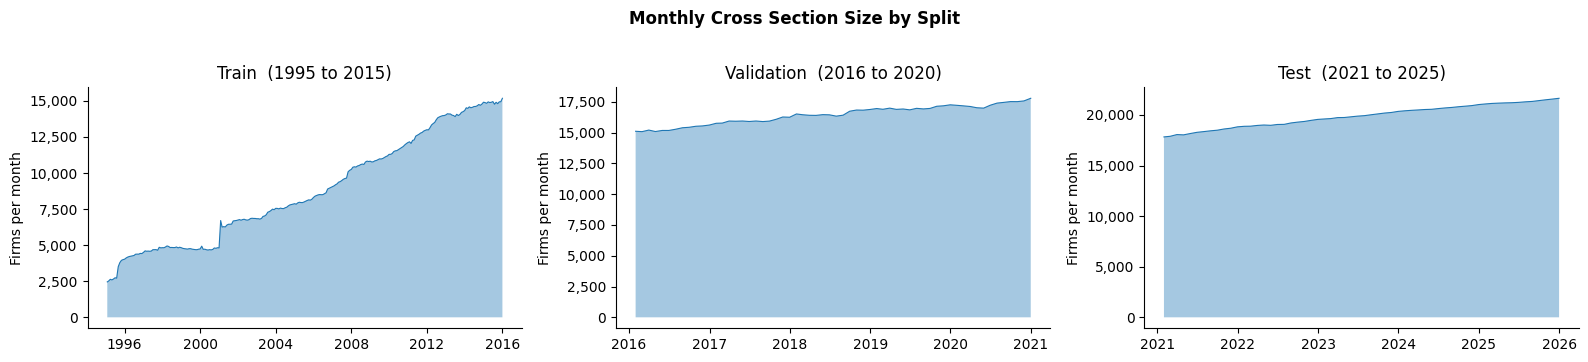

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5), sharey=False)

for ax, (name, df) in zip(axes, splits.items()):
	monthly_n = df.groupby('eom').size()
	ax.fill_between(monthly_n.index, monthly_n.values, alpha=0.4)
	ax.plot(monthly_n.index, monthly_n.values, linewidth=0.8)
	ax.set_title(f"{name}  ({df['eom'].min().year} to {df['eom'].max().year})")
	ax.set_ylabel('Firms per month')
	ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Monthly Cross Section Size by Split',fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Column Structure

Lag columns per depth:
  Lag 12m: 97 columns
  Lag 24m: 97 columns
  Lag 36m: 97 columns
  Lag 48m: 97 columns
  Lag 60m: 97 columns


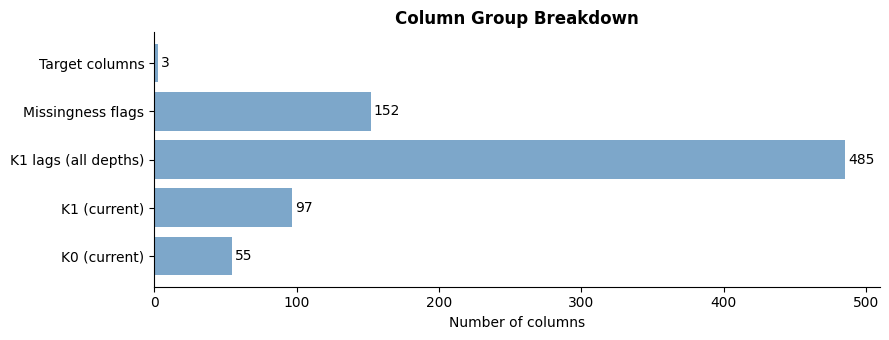

In [5]:
# Lag depth summary
lag_depths = {}
for lag in [12, 24, 36, 48, 60]:
	n = sum(1 for c in lag_cols if c.endswith(f'_lag{lag}'))
	lag_depths[f'Lag {lag}m'] = n

print("Lag columns per depth:")
for k, v in lag_depths.items():
	print(f"  {k}: {v} columns")

# Column type breakdown
col_types = {
	'K0 (current)': len(retained_k0),
	'K1 (current)': len(retained_k1),
	'K1 lags (all depths)': len(lag_cols),
	'Missingness flags': len(flag_cols),
	'Target columns': len(target_cols),
}
fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.barh(list(col_types.keys()), list(col_types.values()),
               color='steelblue', alpha=0.7)
for bar in bars:
	ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
	        f"{int(bar.get_width())}", va='center', fontsize=10)
ax.set_xlabel('Number of columns')
ax.set_title('Column Group Breakdown', fontweight='bold')
plt.tight_layout()
plt.show()

### Automated Tests

The test runner records each assertion with a plain PASS or FAIL label and
accumulates results for the final summary table.

In [6]:
class TestRunner:
	def __init__(self):
		self.results = []

	def check(self, name, condition, info=''):
		status = 'PASS' if condition else 'FAIL'
		self.results.append({
			'name': name, 'status': status, 'info': str(info)
		})
		detail = f'({info})' if info else ''
		print(f"[{status}] {name}{detail}")
		return condition

	def summary(self):
		n_pass = sum(1 for r in self.results if r['status'] == 'PASS')
		n_fail = sum(1 for r in self.results if r['status'] == 'FAIL')
		return n_pass, n_fail


tr = TestRunner()
eps = 1e-4

In [7]:
tr.check("Train starts on 1995-01-31",
         str(train['eom'].min().date()) == '1995-01-31',
         train['eom'].min().date())

tr.check("Train ends on 2015-12-31",
         str(train['eom'].max().date()) == '2015-12-31',
         train['eom'].max().date())

tr.check("Validation starts after 2015-12-31",
         val['eom'].min() > pd.Timestamp('2015-12-31'),
         val['eom'].min().date())

tr.check("Validation ends on 2020-12-31",
         str(val['eom'].max().date()) == '2020-12-31',
         val['eom'].max().date())

tr.check("Test starts after 2020-12-31",
         test['eom'].min() > pd.Timestamp('2020-12-31'),
         test['eom'].min().date())

tr.check("Test ends on 2025-12-31",
         str(test['eom'].max().date()) == '2025-12-31',
         test['eom'].max().date())

tr.check("No date overlap between train and val",
         train['eom'].max() < val['eom'].min())

tr.check("No date overlap between val and test",
         val['eom'].max() < test['eom'].min())

[PASS] Train starts on 1995-01-31(1995-01-31)
[PASS] Train ends on 2015-12-31(2015-12-31)
[PASS] Validation starts after 2015-12-31(2016-01-31)
[PASS] Validation ends on 2020-12-31(2020-12-31)
[PASS] Test starts after 2020-12-31(2021-01-31)
[PASS] Test ends on 2025-12-31(2025-12-31)
[PASS] No date overlap between train and val
[PASS] No date overlap between val and test


True

In [8]:
tr.check("All three splits have identical columns",
         set(train.columns) == set(val.columns) == set(test.columns),
         f"train={train.shape[1]}, val={val.shape[1]}, test={test.shape[1]}")

tr.check("Target columns present in all splits",
         all(c in train.columns for c in ['target_3m', 'target_6m', 'target_12m']))

tr.check("All retained K0 columns present",
         all(c in train.columns for c in retained_k0),
         f"{len(retained_k0)} columns")

tr.check("All retained K1 columns present",
         all(c in train.columns for c in retained_k1),
         f"{len(retained_k1)} columns")

missing_lags = [c for c in lag_cols if c not in train.columns]
tr.check("All lag columns present",
         len(missing_lags) == 0,
         f"{len(missing_lags)} missing" if missing_lags else f"{len(lag_cols)} present")

missing_flags = [f"{c}_miss" for c in retained_k0 + retained_k1
                 if f"{c}_miss" not in train.columns]
tr.check("All missingness flag columns present",
         len(missing_flags) == 0,
         f"{len(missing_flags)} missing" if missing_flags else f"{len(flag_cols)} present")

# Metadata internal consistency check: all_char_cols should equal K0 + K1 + lags

expected_all = set(retained_k0 + retained_k1 + lag_cols)
actual_all = set(all_char_cols)
tr.check("Metadata: all_char_cols = K0 + K1 + lag_cols",
         expected_all == actual_all,
         f"symmetric difference: {len(expected_all.symmetric_difference(actual_all))} columns")

# Flag count should equal K0 + K1 count

expected_flag_count = len(retained_k0) + len(retained_k1)
tr.check("Flag column count equals K0 + K1 count",
         len(flag_cols) == expected_flag_count,
         f"flags={len(flag_cols)}, K0+K1={expected_flag_count}")

# Each lag depth should have the same number of columns (= number of K1 characteristics)

depth_counts = []
for lag in [12, 24, 36, 48, 60]:
	depth_counts.append(sum(1 for c in lag_cols if c.endswith(f'_lag{lag}')))
tr.check("All five lag depths have equal column counts", len(set(depth_counts)) == 1, f"counts per depth: {depth_counts}")

[PASS] All three splits have identical columns(train=838, val=838, test=838)
[PASS] Target columns present in all splits
[PASS] All retained K0 columns present(55 columns)
[PASS] All retained K1 columns present(97 columns)
[PASS] All lag columns present(485 present)
[PASS] All missingness flag columns present(152 present)
[PASS] Metadata: all_char_cols = K0 + K1 + lag_cols(symmetric difference: 0 columns)
[PASS] Flag column count equals K0 + K1 count(flags=152, K0+K1=152)
[PASS] All five lag depths have equal column counts(counts per depth: [97, 97, 97, 97, 97])


True

In [9]:
for name, df in splits.items():
	n_dupes = df.duplicated(subset=['id', 'eom']).sum()
	tr.check(f"{name}: zero duplicate (id, eom) rows",
	         n_dupes == 0,
	         f"{n_dupes:,} duplicates found" if n_dupes else "clean")

# Verify sort order within each split

for name, df in splits.items():
	is_sorted = (df.sort_values(['id', 'eom']).index == df.index).all()
	tr.check(f"{name}: panel sorted by (id, eom)",
	         is_sorted,
	         "sorted" if is_sorted else "not sorted")

[PASS] Train: zero duplicate (id, eom) rows(clean)
[PASS] Validation: zero duplicate (id, eom) rows(clean)
[PASS] Test: zero duplicate (id, eom) rows(clean)
[PASS] Train: panel sorted by (id, eom)(sorted)
[PASS] Validation: panel sorted by (id, eom)(sorted)
[PASS] Test: panel sorted by (id, eom)(sorted)


In [10]:
# K0 + K1 original columns

for name, df in splits.items():
	orig_cols = [c for c in retained_k0 + retained_k1 if c in df.columns]
	vals = df[orig_cols].values
	c_min = float(np.nanmin(vals))
	c_max = float(np.nanmax(vals))
	in_range = (c_min >= -0.5 - eps) and (c_max <= 0.5 + eps)
	tr.check(
		f"{name}: K0+K1 values in [-0.5, 0.5]",
		in_range,
		f"min={c_min:.4f}, max={c_max:.4f}",
	)

# Lag columns value range (excluding NaN from early months)

for name, df in splits.items():
	present_lags = [c for c in lag_cols if c in df.columns]
	if present_lags:

		# Process column by column to avoid large memory allocation
		lag_min = np.inf
		lag_max = -np.inf
		for c in present_lags:
			vals_c = df[c].dropna().values
			if len(vals_c) > 0:
				lag_min = min(lag_min, vals_c.min())
				lag_max = max(lag_max, vals_c.max())
		in_range = (lag_min >= -0.5 - eps) and (lag_max <= 0.5 + eps)
		tr.check(
			f"{name}: lag column values in [-0.5, 0.5]",
			in_range,
			f"min={lag_min:.4f}, max={lag_max:.4f}",
		)

# Flag columns contain only 0 and 1

unique_flag_vals = set()
for col in flag_cols:
	unique_flag_vals.update(train[col].dropna().unique().tolist())
tr.check(
	"Flag columns contain only 0.0 and 1.0",
	unique_flag_vals <= {0.0, 1.0},
	f"unique values found: {sorted(unique_flag_vals)}",
)

[PASS] Train: K0+K1 values in [-0.5, 0.5](min=-0.5000, max=0.5000)
[PASS] Validation: K0+K1 values in [-0.5, 0.5](min=-0.5000, max=0.5000)
[PASS] Test: K0+K1 values in [-0.5, 0.5](min=-0.5000, max=0.5000)
[PASS] Train: lag column values in [-0.5, 0.5](min=-0.5000, max=0.5000)
[PASS] Validation: lag column values in [-0.5, 0.5](min=-0.5000, max=0.5000)
[PASS] Test: lag column values in [-0.5, 0.5](min=-0.5000, max=0.5000)
[PASS] Flag columns contain only 0.0 and 1.0(unique values found: [0.0, 1.0])


True

In [11]:
# K0 + K1 original columns should have zero NaN after imputation

for name, df in splits.items():
	orig_cols = [c for c in retained_k0 + retained_k1 if c in df.columns]
	# Memory-efficient: sum null counts instead of creating boolean array
	null_count = sum(df[c].isnull().sum() for c in orig_cols)
	total_values = sum(len(df) for c in orig_cols)
	null_rate = null_count / total_values if total_values > 0 else 0
	tr.check(f"{name}: K0+K1 null rate < 1%",
	         null_rate < 0.01,
	         f"{null_rate:.4%}")

# Flag columns must never be NaN

for name, df in splits.items():
	null_flags = df[flag_cols].isnull().any().sum()
	tr.check(f"{name}: flag columns have no NaN",
	         null_flags == 0,
	         f"{null_flags} columns with NaN" if null_flags else "clean")

# Lag column nulls: concentrated in early training months only
# In validation and test, all lookback windows should fall within the data,
# so lag columns should have near zero nulls in those splits

for name, df in [('Validation', val), ('Test', test)]:
	lag_null = np.mean([df[c].isnull().mean() for c in lag_cols if c in df.columns])
	tr.check(f"{name}: lag column null rate < 1%",
	         lag_null < 0.01,
	         f"{lag_null:.4%}")

# Training lag nulls are expected in early months but should not persist
# beyond the warmup period. We check that months after 2000-01-31 (five years
# into the sample, covering the longest lag of 60 months) have low null rates

train_post_warmup = train[train['eom'] >= pd.Timestamp('2000-01-31')]
if len(train_post_warmup) > 0:
	lag_null_post = np.mean([
		train_post_warmup[c].isnull().mean()
		for c in lag_cols if c in train_post_warmup.columns
	])
	tr.check("Train (post 2000): lag column null rate < 1%",
	         lag_null_post < 0.01,
	         f"{lag_null_post:.4%}")

# No all NaN columns in any split
for name, df in splits.items():
	all_nan_cols = [c for c in all_char_cols
	               if c in df.columns and df[c].isnull().all()]
	tr.check(f"{name}: no all NaN characteristic columns",
	         len(all_nan_cols) == 0,
	         f"{len(all_nan_cols)} fully null columns" if all_nan_cols else "clean")

[PASS] Train: K0+K1 null rate < 1%(0.0000%)
[PASS] Validation: K0+K1 null rate < 1%(0.0000%)
[PASS] Test: K0+K1 null rate < 1%(0.0000%)
[PASS] Train: flag columns have no NaN(clean)
[PASS] Validation: flag columns have no NaN(clean)
[PASS] Test: flag columns have no NaN(clean)
[PASS] Validation: lag column null rate < 1%(0.0000%)
[PASS] Test: lag column null rate < 1%(0.0000%)
[PASS] Train (post 2000): lag column null rate < 1%(0.0000%)
[PASS] Train: no all NaN characteristic columns(clean)
[PASS] Validation: no all NaN characteristic columns(clean)
[PASS] Test: no all NaN characteristic columns(clean)


In [12]:
# We sample from a well populated month in the middle of the training set.
# The theoretical distribution after rank normalisation is discrete uniform
# on [-0.5, 0.5]. With median imputation introducing ties at rank zero,
# the observed standard deviation will be lower than the continuous uniform
# theoretical value.So, we use a relaxed
# tolerance for the std test.

sample_eom = pd.Timestamp('2010-06-30')
mask = train['eom'] == sample_eom

if mask.sum() == 0:
	sample_eom = train['eom'].unique()[len(train['eom'].unique()) // 2]
	mask = train['eom'] == sample_eom

sample_cols = retained_k0[:10]
sample = train.loc[mask, sample_cols]
N = mask.sum()

means = sample.mean()
mins = sample.min()
maxs = sample.max()

tr.check(f"Cross sectional mean near 0 (N={N:,})",
         (means.abs() < 0.01).all(),
         f"max abs mean = {means.abs().max():.5f}")

tr.check("Cross sectional min = -0.5",
         (mins >= -0.5 - eps).all(),
         f"min of mins = {mins.min():.4f}")

tr.check("Cross sectional max = +0.5",
         (maxs <= 0.5 + eps).all(),
         f"max of maxs = {maxs.max():.4f}")

# The std test uses a wider tolerance to account for imputation induced
# ties which compress the rank distribution below the theoretical uniform.

expected_std = 1 / np.sqrt(12)
actual_std = sample.std().mean()
tr.check("Cross sectional std within expected range",
         actual_std > 0.15 and actual_std <= expected_std + 0.02,
         f"mean col std = {actual_std:.4f}, theoretical uniform = {expected_std:.4f}")

# Verify that the normalisation formula produces identical results when
# recomputed on this cross section from scratch.
test_col = sample_cols[0]
raw_ranks = sample[test_col].rank(method='average')
recomputed = (raw_ranks - 1) / (N - 1) - 0.5
max_diff = (sample[test_col] - recomputed).abs().max()
tr.check("Rank formula reproduces stored values",
         max_diff < 1e-3,
         f"max absolute difference = {max_diff:.6f}")

[PASS] Cross sectional mean near 0 (N=11,622)(max abs mean = 0.00000)
[PASS] Cross sectional min = -0.5(min of mins = -0.5000)
[PASS] Cross sectional max = +0.5(max of maxs = 0.5000)
[PASS] Cross sectional std within expected range(mean col std = 0.2259, theoretical uniform = 0.2887)
[PASS] Rank formula reproduces stored values(max absolute difference = 0.000000)


np.True_

In [13]:
# Where a flag equals 1 (value was missing before imputation), the normalised
# characteristic should be near zero because the imputed median maps to the
# centre of the cross sectional rank distribution. We test a sample of K0,
# K1, and lag columns.

tested = 0
for col_list, label in [(retained_k1, 'K1'), (retained_k0, 'K0'), (lag_cols[:20], 'lag')]:
	for col in col_list:
		flag_col = f'{col}_miss' if not col.endswith('_miss') else col
		# Lag columns share the base characteristic flag
		if label == 'lag':
			# Extract base name: e.g. 'roe_lag12' -> 'roe'
			base = col.rsplit('_lag', 1)[0] if '_lag' in col else col
			flag_col = f'{base}_miss'
		if flag_col not in train.columns or col not in train.columns:
			continue
		flagged = train[flag_col] == 1.0
		if flagged.sum() < 100:
			continue
		mean_abs = train.loc[flagged, col].abs().mean()
		tr.check(f"Flag=1 rows of '{col}' have abs value near 0",
		         mean_abs < 0.05,
		         f"mean abs normalised value = {mean_abs:.4f}")
		tested += 1
		if tested >= 8:
			break
	if tested >= 8:
		break

[PASS] Flag=1 rows of 'at_gr1' have abs value near 0(mean abs normalised value = 0.0000)
[PASS] Flag=1 rows of 'sale_gr1' have abs value near 0(mean abs normalised value = 0.0000)
[PASS] Flag=1 rows of 'inv_gr1a' have abs value near 0(mean abs normalised value = 0.0035)
[PASS] Flag=1 rows of 'fnl_gr1a' have abs value near 0(mean abs normalised value = 0.0025)
[PASS] Flag=1 rows of 'nfna_gr1a' have abs value near 0(mean abs normalised value = 0.0002)
[PASS] Flag=1 rows of 'tax_gr1a' have abs value near 0(mean abs normalised value = 0.0013)
[PASS] Flag=1 rows of 'be_gr1a' have abs value near 0(mean abs normalised value = 0.0000)
[PASS] Flag=1 rows of 'ebit_sale' have abs value near 0(mean abs normalised value = 0.0000)


In [14]:
# Target columns should have reasonable null rates
for name, df in splits.items():
	null_rates = {c: df[c].isnull().mean() for c in target_cols}
	max_null = max(null_rates.values())
	tr.check(f"{name}: target null rate < 60%",
	         max_null < 0.60,
	         '  '.join(f"{c}: {v:.1%}" for c, v in null_rates.items()))

# Null rate monotonicity: 3m < 6m < 12m within each split, because longer
# horizons lose more observations at the end of the sample window.
for name, df in splits.items():
	nr_3 = df['target_3m'].isnull().mean()
	nr_6 = df['target_6m'].isnull().mean()
	nr_12 = df['target_12m'].isnull().mean()
	tr.check(f"{name}: target null rate monotonic (3m < 6m < 12m)",
	         nr_3 <= nr_6 <= nr_12,
	         f"3m={nr_3:.3%}, 6m={nr_6:.3%}, 12m={nr_12:.3%}")

# Target means should be within a plausible range for cumulative excess
# returns. EM equities carry a positive risk premium that accumulates
# over longer horizons, so the tolerance scales with the forecast
# horizon: 0.02 per month allows for a monthly risk premium of up to
# 2% before the test flags an anomaly

for h in [3, 6, 12]:
	col = f'target_{h}m'
	data = train[col].dropna()
	tolerance = 0.02 * h
	tr.check(f"Train {col} mean within plausible range",
	         abs(data.mean()) < tolerance,
	         f"mean={data.mean():.4f}, std={data.std():.4f}, "
	         f"tolerance={tolerance:.2f}")

[PASS] Train: target null rate < 60%(target_3m: 0.7%  target_6m: 1.4%  target_12m: 2.7%)
[PASS] Validation: target null rate < 60%(target_3m: 0.5%  target_6m: 1.0%  target_12m: 2.1%)
[PASS] Test: target null rate < 60%(target_3m: 5.9%  target_6m: 11.6%  target_12m: 22.9%)
[PASS] Train: target null rate monotonic (3m < 6m < 12m)(3m=0.683%, 6m=1.354%, 12m=2.687%)
[PASS] Validation: target null rate monotonic (3m < 6m < 12m)(3m=0.509%, 6m=1.028%, 12m=2.063%)
[PASS] Test: target null rate monotonic (3m < 6m < 12m)(3m=5.863%, 6m=11.614%, 12m=22.881%)
[PASS] Train target_3m mean within plausible range(mean=0.0359, std=0.3560, tolerance=0.06)
[PASS] Train target_6m mean within plausible range(mean=0.0768, std=0.5523, tolerance=0.12)
[PASS] Train target_12m mean within plausible range(mean=0.1738, std=0.9928, tolerance=0.24)


In [15]:
# After rank normalisation, the lag12 value at month t and the current
# value at month t minus 12 are ranked within different cross sections
# (different months have different firm compositions). Exact equality
# is therefore not expected. Instead we verify two structural properties.
#
# First, the Spearman rank correlation between the lag12 column and the
# corresponding current column should be positive and substantial for
# slowly moving accounting characteristics.
#
# Second, the non null rate should decrease monotonically with lag depth
# in the training set because deeper lags require more historical data.

if retained_k1:
	test_chars = retained_k1[:3]
	for test_char in test_chars:
		lag12_col = f"{test_char}_lag12"
		if lag12_col not in train.columns:
			continue

		# Use a subsample to keep computation fast
		sub = train[[test_char, lag12_col]].dropna().head(50000)
		if len(sub) < 100:
			continue

		corr, pval = spearmanr(sub[test_char], sub[lag12_col])
		tr.check(
			f"Rank corr of '{test_char}' vs lag12 is positive", corr > 0.0, f"Spearman rho = {corr:.4f}, p = {pval:.2e}"
		)

# Non null count should decrease with lag depth in the training set
# because deeper lags require more historical data
if lag_cols:
	depth_nonnull = {}
	for lag in [12, 24, 36, 48, 60]:
		depth_cols = [c for c in lag_cols if c.endswith(f"_lag{lag}")]
		if depth_cols:
			avg_nonnull = np.mean([train[c].notna().mean() for c in depth_cols])
			depth_nonnull[lag] = avg_nonnull

	if len(depth_nonnull) == 5:
		vals = [depth_nonnull[l] for l in [12, 24, 36, 48, 60]]
		monotonic = all(vals[i] >= vals[i + 1] - 0.01 for i in range(4))
		tr.check("Lag non null rate decreases with depth (train)", monotonic,
			", ".join(f"lag{l}: {depth_nonnull[l]:.3f}" for l in [12, 24, 36, 48, 60])
		)

[PASS] Rank corr of 'at_gr1' vs lag12 is positive(Spearman rho = 0.1451, p = 2.54e-233)
[PASS] Rank corr of 'sale_gr1' vs lag12 is positive(Spearman rho = 0.0689, p = 1.32e-53)
[PASS] Rank corr of 'inv_gr1a' vs lag12 is positive(Spearman rho = 0.0972, p = 3.63e-105)
[PASS] Lag non null rate decreases with depth (train)(lag12: 0.983, lag24: 0.960, lag36: 0.934, lag48: 0.908, lag60: 0.882)


### Distribution Analysis

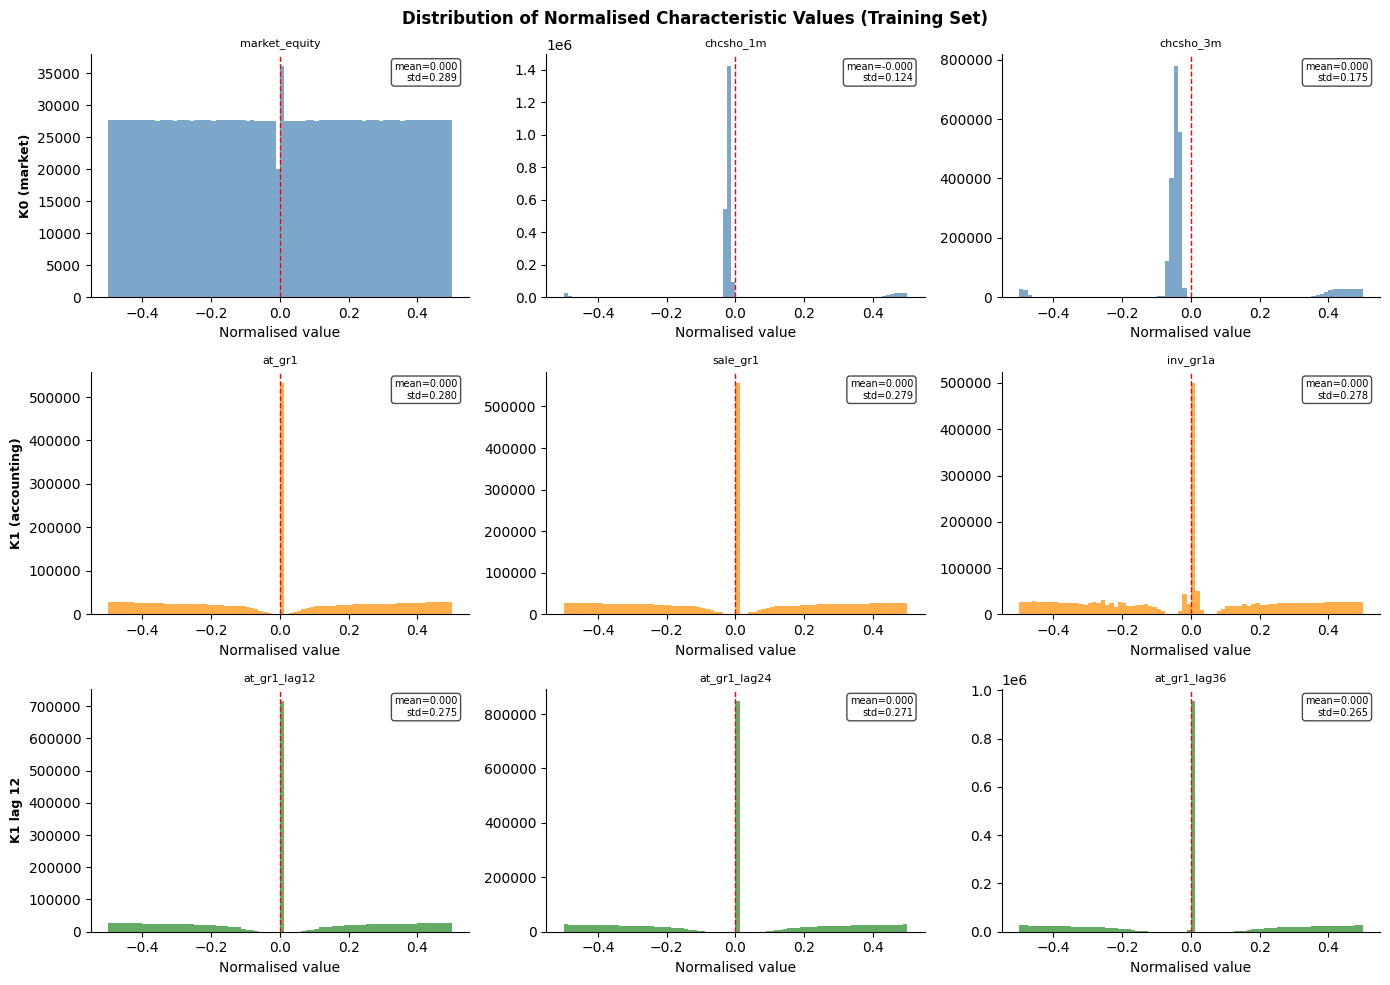

In [16]:
# Distribution of normalised values for a sample of K0, K1, and lag columns

sample_k0 = retained_k0[:3]
sample_k1 = retained_k1[:3]
sample_lag = lag_cols[:3]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
groups = [('K0 (market)', sample_k0, 'steelblue'),
          ('K1 (accounting)', sample_k1, 'darkorange'),
          ('K1 lag 12', sample_lag, 'forestgreen')]

for row_idx, (group_name, cols, color) in enumerate(groups):
	for col_idx, col in enumerate(cols):
		ax = axes[row_idx, col_idx]
		val_data = train[col].dropna()
		ax.hist(val_data, bins=80, color=color, alpha=0.7, edgecolor='none')
		ax.axvline(0, color='red', linewidth=1, linestyle='dashed', label='0')
		ax.set_title(f"{col[:30]}", fontsize=8)
		ax.set_xlabel('Normalised value')
		if col_idx == 0:
			ax.set_ylabel(group_name, fontsize=9, fontweight='bold')
		stats_text = f"mean={val_data.mean():.3f}\nstd={val_data.std():.3f}"
		ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
		        fontsize=7, va='top', ha='right',
		        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

fig.suptitle('Distribution of Normalised Characteristic Values (Training Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Null rates per column group and split (computed column by column
# to avoid materialising large multi column arrays)

def col_null_rate(df, cols):
	present = [c for c in cols if c in df.columns]
	if not present:
		return 0.0
	return float(np.mean([df[c].isnull().mean() for c in present]))


null_summary = []
for name, df in splits.items():
	null_summary.append({
		'Split': name,
		'K0': f"{col_null_rate(df, retained_k0):.3%}",
		'K1': f"{col_null_rate(df, retained_k1):.3%}",
		'K1 lags': f"{col_null_rate(df, lag_cols):.3%}",
		'Flags': f"{col_null_rate(df, flag_cols):.3%}",
		'target_3m': f"{df['target_3m'].isnull().mean():.3%}",
		'target_6m': f"{df['target_6m'].isnull().mean():.3%}",
		'target_12m': f"{df['target_12m'].isnull().mean():.3%}",
	})

print("Mean null rate per column group and split:\n")
pd.DataFrame(null_summary).set_index('Split')

Mean null rate per column group and split:



,K0,K1,K1 lags,Flags,target_3m,target_6m,target_12m
Split,,,,,,,
Train,0.000%,0.000%,6.671%,0.000%,0.683%,1.354%,2.687%
Validation,0.000%,0.000%,0.000%,0.000%,0.509%,1.028%,2.063%
Test,0.000%,0.000%,0.000%,0.000%,5.863%,11.614%,22.881%


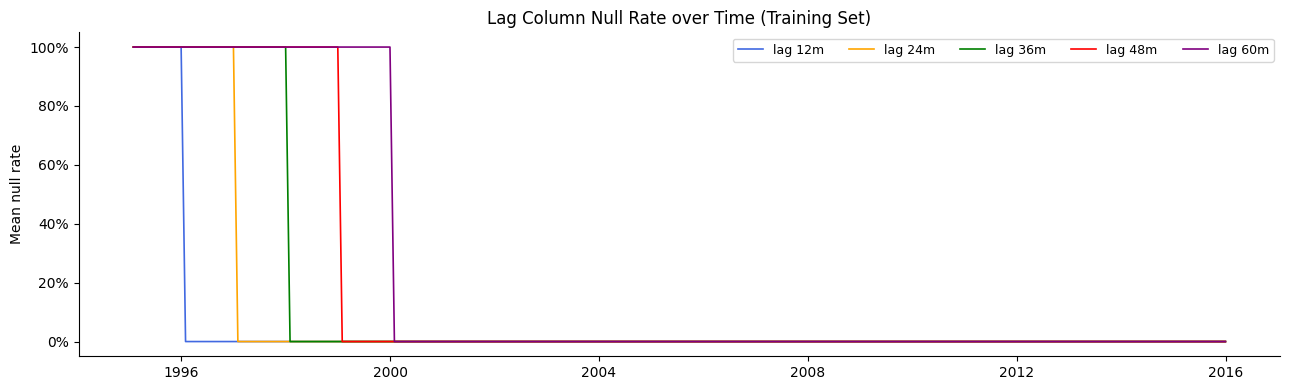

In [18]:
# Lag column null rate by lag depth over time (training set only)

fig, ax = plt.subplots(figsize=(13, 4))

for lag, color in zip([12, 24, 36, 48, 60],
                       ['royalblue', 'orange', 'green', 'red', 'purple']):
	depth_cols = [c for c in lag_cols if c.endswith(f'_lag{lag}')]
	monthly_null = (train.groupby('eom')[depth_cols]
	                .apply(lambda g: g.isnull().mean().mean()))
	ax.plot(monthly_null.index, monthly_null.values,
	        label=f'lag {lag}m', color=color, linewidth=1.2)

ax.set_ylabel('Mean null rate')
ax.set_title('Lag Column Null Rate over Time (Training Set)')
ax.legend(ncol=5, fontsize=9)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

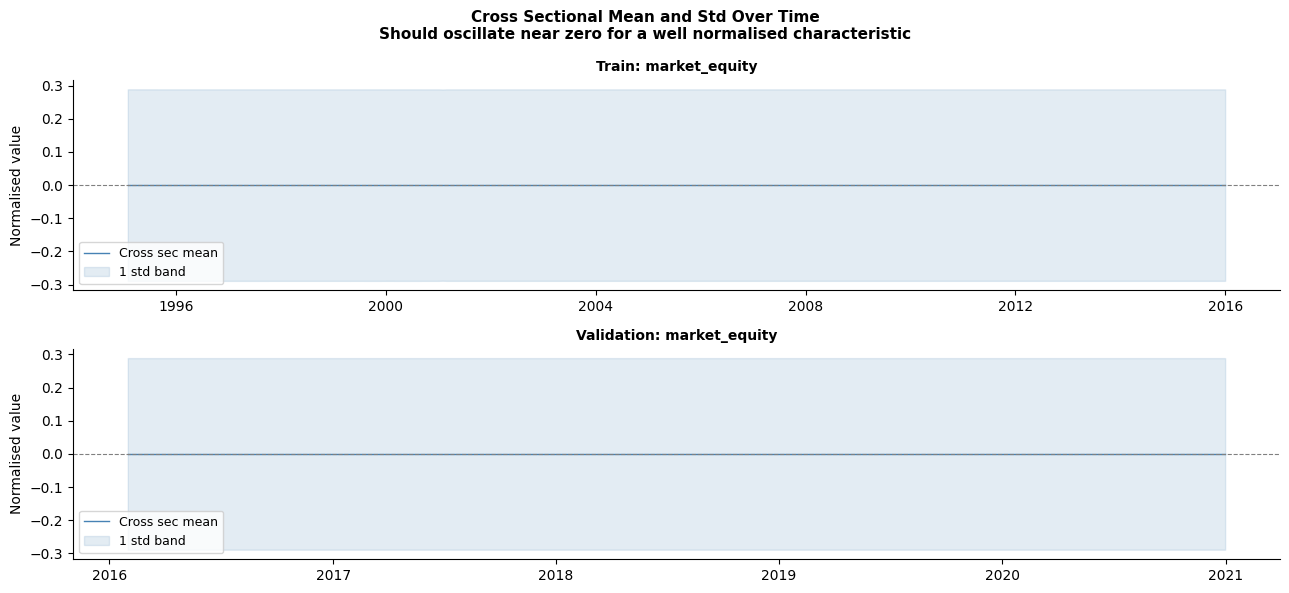

In [19]:
# Cross sectional mean and std of a K0 characteristic over time

col = retained_k0[0]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)

for ax, (name, df) in zip(axes, [('Train', train), ('Validation', val)]):
	monthly_mean = df.groupby('eom')[col].mean()
	monthly_std = df.groupby('eom')[col].std()
	ax.plot(monthly_mean.index, monthly_mean.values,
	        label='Cross sec mean', color='steelblue', linewidth=1)
	ax.fill_between(monthly_std.index, monthly_mean - monthly_std, monthly_mean + monthly_std,
	                alpha=0.15, color='steelblue', label='1 std band')
	ax.axhline(0, color='grey', linewidth=0.8, linestyle='dashed')
	ax.set_title(f"{name}: {col}", fontsize=10, fontweight='bold')
	ax.set_ylabel('Normalised value')
	ax.legend(fontsize=9)

fig.suptitle('Cross Sectional Mean and Std Over Time\n'
             'Should oscillate near zero for a well normalised characteristic',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### Target Return Analysis

In [20]:
# Summary statistics for target columns
print("Target column summary (training set):\n")
desc = train[target_cols].describe(
	percentiles=[.01, .05, .25, .5, .75, .95, .99])
desc

Target column summary (training set):



,target_3m,target_6m,target_12m
count,2.193864e+06,2.179041e+06,2.149601e+06
mean,3.593381e-02,7.681827e-02,1.737777e-01
std,3.560165e-01,5.523001e-01,9.927626e-01
min,-9.520432e-01,-9.945516e-01,-9.977064e-01
1%,-6.110699e-01,-7.406836e-01,-8.578466e-01
5%,-3.912550e-01,-5.237579e-01,-6.619202e-01
25%,-1.461829e-01,-2.085209e-01,-2.946457e-01
50%,-8.870460e-03,-1.183242e-02,-1.347111e-02
75%,1.480875e-01,2.304867e-01,3.746867e-01
95%,5.965397e-01,9.428488e-01,1.561960e+00


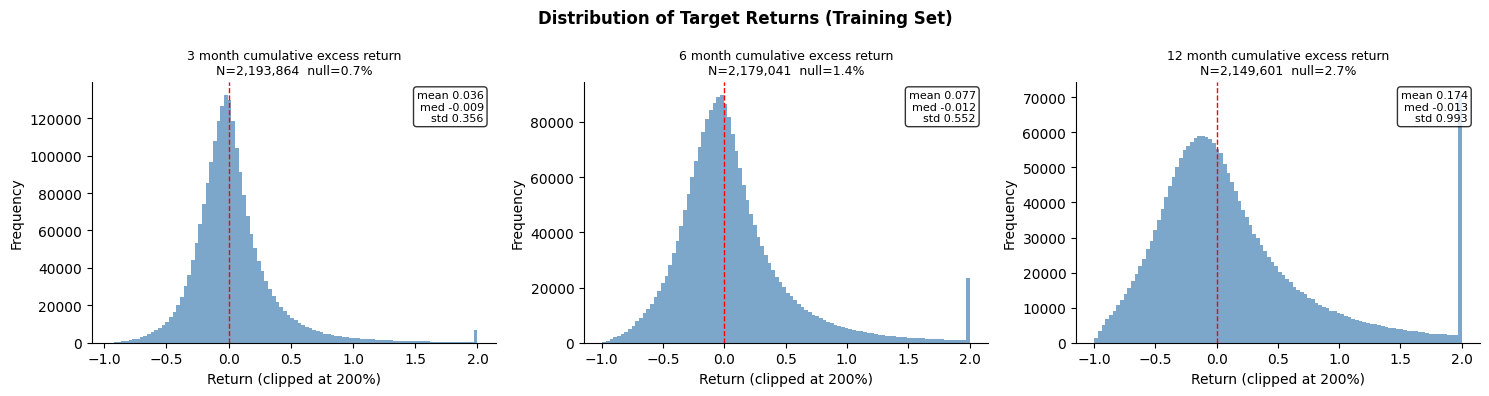

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, target_cols):
	h_months = int(col.split('_')[1].replace('m', ''))
	data = train[col].dropna()

	# Clip to [-2, 2] for visualisation
	clipped = data.clip(-2, 2)
	ax.hist(clipped, bins=100, color='steelblue', alpha=0.7, edgecolor='none')
	ax.axvline(0, color='red', linewidth=1, linestyle='dashed')
	ax.set_title(f"{h_months} month cumulative excess return\n"
	             f"N={len(data):,}  null={train[col].isnull().mean():.1%}", fontsize=9)
	ax.set_xlabel('Return (clipped at 200%)')
	ax.set_ylabel('Frequency')
	stats = (f"mean {data.mean():.3f}\n"
	         f"med {data.median():.3f}\n"
	         f"std {data.std():.3f}")
	ax.text(0.97, 0.97, stats, transform=ax.transAxes,
	        fontsize=8, va='top', ha='right',
	        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle('Distribution of Target Returns (Training Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

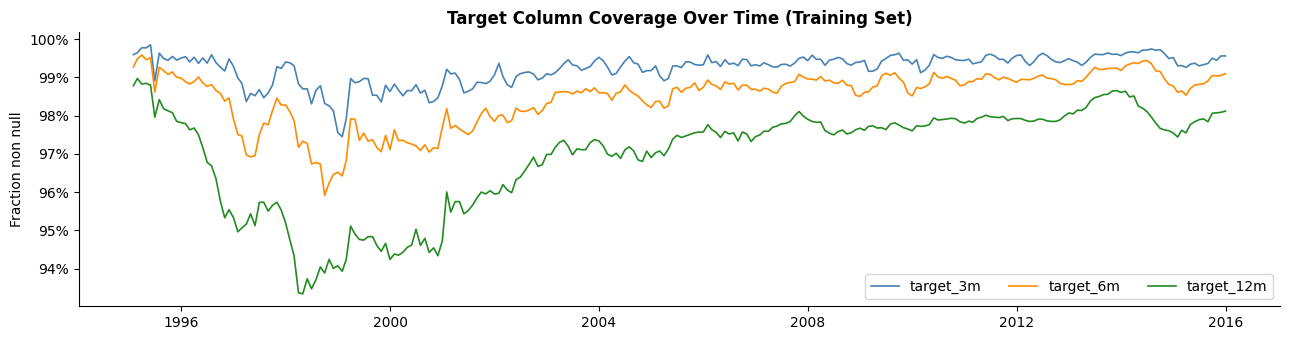

In [22]:
# Target availability over time
fig, ax = plt.subplots(figsize=(13, 3.5))

for col, color in zip(target_cols, ['steelblue', 'darkorange', 'forestgreen']):
	monthly_coverage = train.groupby('eom')[col].apply(
		lambda x: x.notna().mean())
	ax.plot(monthly_coverage.index, monthly_coverage.values,
	        label=col, color=color, linewidth=1.2)


ax.set_ylabel('Fraction non null')

# Coverage drops at the end as forward returns fall outside the sample window
ax.set_title('Target Column Coverage Over Time (Training Set)', fontweight='bold')
ax.legend(ncol=3)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

### Test Summary

In [23]:
n_pass, n_fail = tr.summary()

rows = []
for r in tr.results:
	rows.append({
		'Test': r['name'],
		'Result': r['status'],
		'Detail': r['info'],
	})

df_results = pd.DataFrame(rows)

print(f"\nTotal: {n_pass + n_fail} tests, {n_pass} passed, {n_fail} failed\n")
if n_fail == 0:
	print("All tests passed")
else:
	print(f"{n_fail} test(s) failed")
print()
df_results


Total: 68 tests, 68 passed, 0 failed

All tests passed



,Test,Result,Detail
0,Train starts on 1995-01-31,PASS,1995-01-31
1,Train ends on 2015-12-31,PASS,2015-12-31
2,Validation starts after 2015-12-31,PASS,2016-01-31
3,Validation ends on 2020-12-31,PASS,2020-12-31
4,Test starts after 2020-12-31,PASS,2021-01-31
...,...,...,...
63,Train target_12m mean within plausible range,PASS,"mean=0.1738, std=0.9928, tolerance=0.24"
64,Rank corr of 'at_gr1' vs lag12 is positive,PASS,"Spearman rho = 0.1451, p = 2.54e-233"
65,Rank corr of 'sale_gr1' vs lag12 is positive,PASS,"Spearman rho = 0.0689, p = 1.32e-53"
66,Rank corr of 'inv_gr1a' vs lag12 is positive,PASS,"Spearman rho = 0.0972, p = 3.63e-105"


### Data Columns to JSON

In [3]:
for name in ['train', 'val', 'test']:
	df = pd.read_parquet(output_dir / f'{name}.parquet')
	print(f"{name}: {len(df.columns)} columns, {df.shape[0]:,} rows")

	with open(output_dir / f'{name}_columns.json', 'w') as f:
		json.dump(list(df.columns), f, indent=2)

	del df

print(f"\nSaved to {output_dir}")

train: 838 columns, 2,208,946 rows
val: 838 columns, 985,346 rows
test: 838 columns, 1,192,494 rows

Saved to ..\data\processed
